In [53]:
import numpy as np
import matplotlib.pyplot as plt

"""
    Este codigo busca realizar la vectorización de la matriz de densidad 
    y obtener los eigenvalores derechos e izquierdos del superoperador L (Liouvilliano),
    al hacer la vectorización de rho L se vuelve un operador
"""
# Construí una función que vectoriza la matriz de densidad, sin embargo es mejor usar np.flatten()
def vectzn(rho):
    n, m = rho.shape
    v = np.zeros(n * m)

    x = 0
    for j in range(n):      # i,j es la posición de un elemento de la matriz, en esta linea se fija j
        for i in range(m):  # Empieza el ciclo y recorre todos los i en el rango m = 0,1,2,..., m, termina y cambia j.
            v[x] = rho[i, j]
            x += 1

    return v



"""
- H: matriz del Hamiltoniano
- jump_ops: Array de los operadores de salto Ex.[S_]
"""
def liouvilliano(H, jump_ops):    
    N = len(H)
    I = np.identity(N, dtype=complex)
    alpha = -1j* (np.kron(I,H) - np.kron(H.T,I))

    n = len(jump_ops)
    D = np.zeros((N**2,N**2), dtype=complex)
    
    for i in range(n):
        LdagL = jump_ops[i].conj().T@jump_ops[i]
        D += np.kron(jump_ops[i].conj() , jump_ops[i]) - (1/2)* (np.kron(I, LdagL)+ np.kron((LdagL).T, I))
    return alpha + D
# Construyendo rho, para 2 spins + en z: 

up   = np.array([1,0])
down = np.array([0,1])
psi = np.kron(up,up)   # |psi> = |+> ptensor |+> Esto es una matriz 2x2
print('|psi> = ',psi)

rho = np.outer(psi, psi.conj().T) # |psi><psi|
print(rho)

rho = vectzn(rho) # Vectorizar la matriz de densidad
print('|rho>> = ',rho, "\n -------------------------------------------------------------------------")

# Ejemplo con una matriz cualquiera
A = np.array([[1,2],[3,4]])

print(vectzn(A))        # [1,3,2,4]
print(A.flatten())      # [1,2,3,4]
print(A.flatten(order = 'F'), "\n -------------------------------------------------------------------------")   # [1,3,2,4]

# Ahora contruyamos el Liouvilliano

# Matriz Identidad (I)
I = np.array([[1, 0], [0, 1]], dtype=complex)

# Matrices de Pauli
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

# Definiendo operadores S para 2 spins

Sx =(1/2) * (np.kron(X,I)+ np.kron(I,X))
Sy =(1/2) * (np.kron(Y,I)+ np.kron(I,Y))
Sz =(1/2) * (np.kron(Z,I)+ np.kron(I,Z))
Sp = Sx + Sy *1j 
Sm = Sp.conj().T


w = 0.5
H = 1/2 * w * (np.kron(X,I)+ np.kron(I,X))
          
L = liouvilliano(H,[Sm])
print('dim Hilbert = ', len(psi))
print('dimL = N^2 x N^2 ',L.shape)  # dimL = N^2 * N^2, donde N es la dim del espacio de Hilbert (4 = 2*2) 2 spin

eigs, eigsvec = np.linalg.eig(L) 

|psi> =  [1 0 0 0]
[[1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
|rho>> =  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 
 -------------------------------------------------------------------------
[1. 3. 2. 4.]
[1 2 3 4]
[1 3 2 4] 
 -------------------------------------------------------------------------
dim Hilbert =  4
dimL = N^2 x N^2  (16, 16)


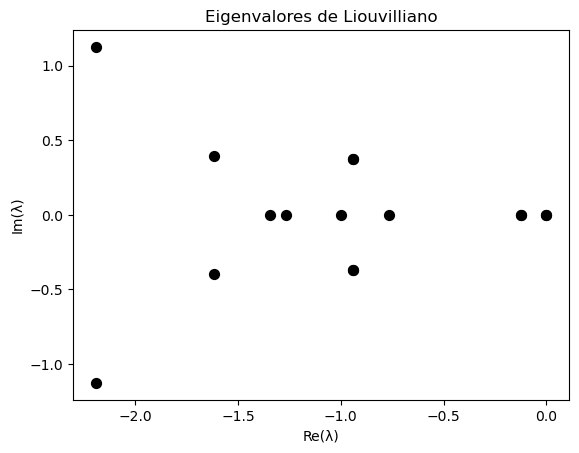

In [47]:
X = np.real(eigs)
Y = np.imag(eigs)

plt.scatter(X,Y, s=50, c='black')
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalores de Liouvilliano")
#plt.savefig("evalues100.png")
plt.show()